<a href="https://colab.research.google.com/github/Khushibung05/RNN_LSTM_GRU/blob/main/simplernn_lstm_gruipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, GRU, SimpleRNN
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score


### Task 1: Dataset Analysis

IMDB dataset from Keras was intentionally released with a fixed train/test split so that researchers can compare results fairly.

The data returned by imdb.load_data() is not the raw review text. It is already tokenized and encoded as integers:[1, 14, 22, 16, 43, ...]

In [27]:
from tensorflow.keras.datasets import imdb
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

reviews = list(X_train) + list(X_test)
labels = list(y_train) + list(y_test)
# Number of reviews
total_reviews = len(reviews)

# Positive and negative review counts
positive_reviews = sum(labels)#sum of all 1's
negative_reviews = total_reviews - positive_reviews#all 0's

# Review lengths
review_lengths = [len(review) for review in reviews]

# Statistics
avg_length = sum(review_lengths) / len(review_lengths)
longest_review = max(review_lengths)
shortest_review = min(review_lengths)

# Display results
print("Number of Reviews      :", total_reviews)
print("Positive Reviews Count :", positive_reviews)
print("Negative Reviews Count :", negative_reviews)
print("Average Review Length  :", round(avg_length, 2))
print("Longest Review Length  :", longest_review)
print("Shortest Review Length :", shortest_review)

Number of Reviews      : 50000
Positive Reviews Count : 25000
Negative Reviews Count : 25000
Average Review Length  : 234.76
Longest Review Length  : 2494
Shortest Review Length : 7


Since review lengths vary greatly, padding and truncation will be required before training SimpleRNN, LSTM, and GRU models.

The reviews are already preprocessed and tokenized. They are stored as integer sequences, not raw text.

Example:

print(X_train[0])

Output:

[1, 14, 22, 16, 43, 530, ...]

| Step                 | Needed?      |
| -------------------- | ------------ |
| Lowercase conversion | Already done |
| HTML removal         | Already done |
| Punctuation removal  | Already done |
| Stopword removal     | Not done     |
| Tokenization         | Already done |
| Sequence generation  | Already done |
| Padding              | Required     |


In [28]:
print(X_train)
print("y:",y_train)

[list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32])
 list([1, 194, 1153, 194, 8255, 78, 228, 5, 6, 1463, 

In [29]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
# Padding
maxlen = 500

X_train = pad_sequences(
    X_train,
    maxlen=maxlen,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=maxlen,
    padding='post',
    truncating='post'
)

print(X_train.shape)
print(X_test.shape)
#no need to pad y since theres only 1 value for each...
print(y_train.shape)
print(y_test.shape)


(25000, 500)
(25000, 500)
(25000,)
(25000,)


###**Build RNN,LSTM,GRU models**

###SimpleRNN

In [30]:
model_rnn = Sequential([

    Embedding(
        input_dim=vocab_size,
        output_dim=32,
        input_length=maxlen
    ),

    SimpleRNN(32),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')
])

model_rnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
model_rnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

###LSTM

In [32]:
model_lstm = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=maxlen),
    LSTM(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_lstm.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

###GRU

In [33]:
model_gru = Sequential([
    Embedding(input_dim=vocab_size, output_dim=32, input_length=maxlen),
    GRU(32),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_gru.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_gru.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

###**comparision**

In [34]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
import pandas as pd
import time

#measuring rnn training time
start = time.time()

history_rnn = model_rnn.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

rnn_time = time.time() - start
print("RNN Training Time:", rnn_time, "seconds")

#lstm training time
start = time.time()

history_lstm = model_lstm.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)
lstm_time = time.time() - start
print("LSTM Training Time:", lstm_time, "seconds")

#gru training time
start = time.time()

history_gru = model_gru.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)
gru_time = time.time() - start
print("GRU Training Time:", gru_time, "seconds")



Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - accuracy: 0.5016 - loss: 0.6938 - val_accuracy: 0.5008 - val_loss: 0.6942
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - accuracy: 0.5043 - loss: 0.6926 - val_accuracy: 0.4988 - val_loss: 0.6940
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.5084 - loss: 0.6898 - val_accuracy: 0.5052 - val_loss: 0.6943
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - accuracy: 0.5054 - loss: 0.6900 - val_accuracy: 0.5036 - val_loss: 0.6947
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.5293 - loss: 0.6703 - val_accuracy: 0.5062 - val_loss: 0.7077
RNN Training Time: 72.83117890357971 seconds
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 29ms/step - accuracy: 0.5048 - loss: 0.6929 - val_accuracy: 0.5038 - val_loss: 0.6929
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.5207 - loss: 0.6879 - val_accuracy: 0.5170 - val_loss: 0.6917
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step -

In [35]:
rnn_pred = model_rnn.predict(X_test)

rnn_pred = (rnn_pred > 0.5).astype(int)

lstm_pred = model_lstm.predict(X_test)

lstm_pred = (lstm_pred > 0.5).astype(int)

gru_pred = model_gru.predict(X_test)

gru_pred = (gru_pred > 0.5).astype(int)

782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step
782/782 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step


In [36]:
#rnn metrics
rnn_accuracy = accuracy_score(y_test, rnn_pred)

rnn_precision = precision_score(y_test, rnn_pred)

rnn_recall = recall_score(y_test, rnn_pred)

rnn_f1 = f1_score(y_test, rnn_pred)

#lstm metrics
lstm_accuracy = accuracy_score(y_test, lstm_pred)

lstm_precision = precision_score(y_test, lstm_pred)

lstm_recall = recall_score(y_test, lstm_pred)

lstm_f1 = f1_score(y_test, lstm_pred)

#gru metrics
gru_accuracy = accuracy_score(y_test, gru_pred)

gru_precision = precision_score(y_test, gru_pred)

gru_recall = recall_score(y_test, gru_pred)

gru_f1 = f1_score(y_test, gru_pred)

In [37]:
#validation accuracy and loss
#rnn
rnn_val_acc = max(history_rnn.history['val_accuracy'])
rnn_val_loss = min(history_rnn.history['val_loss'])
#lstm
lstm_val_acc = max(history_lstm.history['val_accuracy'])
lstm_val_loss = min(history_lstm.history['val_loss'])
#gru
gru_val_acc = max(history_gru.history['val_accuracy'])
gru_val_loss = min(history_gru.history['val_loss'])


In [38]:
#parameter count
rnn_params = model_rnn.count_params()

lstm_params = model_lstm.count_params()

gru_params = model_gru.count_params()

In [39]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Training Time (sec)",
        "Validation Accuracy",
        "Validation Loss",
        "Parameters"
    ],

    "SimpleRNN":[
        rnn_accuracy,
        rnn_precision,
        rnn_recall,
        rnn_f1,
        rnn_time,
        rnn_val_acc,
        rnn_val_loss,
        rnn_params
    ],

    "LSTM":[
        lstm_accuracy,
        lstm_precision,
        lstm_recall,
        lstm_f1,
        lstm_time,
        lstm_val_acc,
        lstm_val_loss,
        lstm_params
    ],

    "GRU":[
        gru_accuracy,
        gru_precision,
        gru_recall,
        gru_f1,
        gru_time,
        gru_val_acc,
        gru_val_loss,
        gru_params
    ]
})

print(comparison)

                Metric      SimpleRNN           LSTM            GRU
0             Accuracy       0.505360       0.514160       0.506240
1            Precision       0.558059       0.670520       0.581590
2               Recall       0.051520       0.055680       0.044480
3             F1 Score       0.094331       0.102822       0.082640
4  Training Time (sec)      72.831179      42.587500      43.912407
5  Validation Accuracy       0.506200       0.525000       0.511000
6      Validation Loss       0.693981       0.691411       0.693827
7           Parameters  322625.000000  328865.000000  326881.000000


###accuracy comparision graph

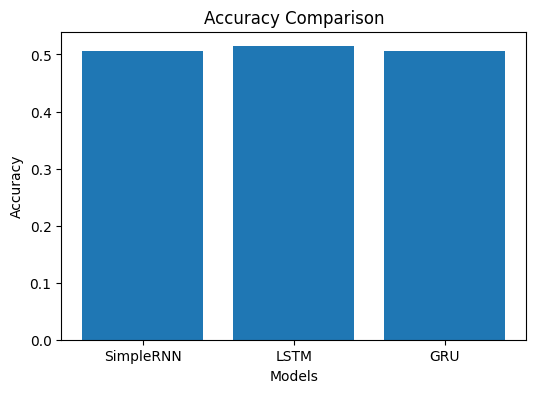

In [42]:
import matplotlib.pyplot as plt

models = ["SimpleRNN", "LSTM", "GRU"]

accuracies = [
    rnn_accuracy,
    lstm_accuracy,
    gru_accuracy
]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)

plt.title("Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

###loss comparision graph

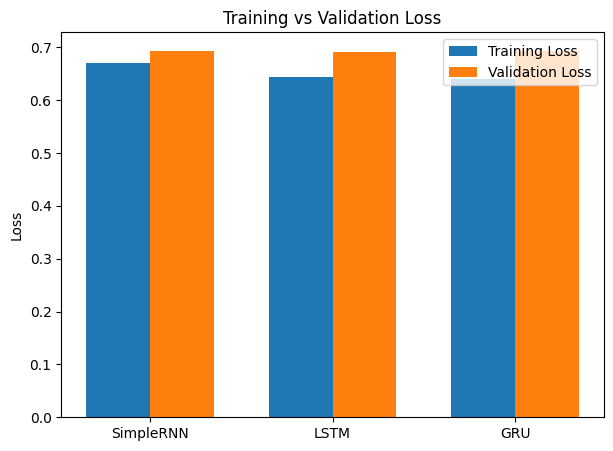

In [41]:
models = ["SimpleRNN", "LSTM", "GRU"]

train_loss = [
    min(history_rnn.history['loss']),
    min(history_lstm.history['loss']),
    min(history_gru.history['loss'])
]

val_loss = [
    min(history_rnn.history['val_loss']),
    min(history_lstm.history['val_loss']),
    min(history_gru.history['val_loss'])
]
x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(7,5))

plt.bar(x-width/2, train_loss, width, label="Training Loss")
plt.bar(x+width/2, val_loss, width, label="Validation Loss")

plt.xticks(x, models)

plt.title("Training vs Validation Loss")
plt.ylabel("Loss")
plt.legend()

plt.show()

##training time comparision


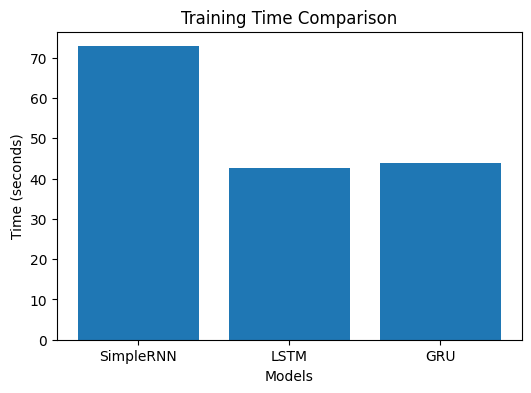

In [43]:
models = ["SimpleRNN", "LSTM", "GRU"]

training_times = [
    rnn_time,
    lstm_time,
    gru_time
]

plt.figure(figsize=(6,4))

plt.bar(models, training_times)

plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Time (seconds)")

plt.show()

###REAL TIME PREDICTION


In [49]:
word_index = imdb.get_word_index()
def encode_review(review):

    words = review.lower().split()

    encoded = []

    for word in words:
        if word in word_index:
            encoded.append(word_index[word] + 3)

    return pad_sequences([encoded], maxlen=500)

In [50]:
reviews = [
    "This movie was absolutely fantastic and I enjoyed every minute",
    "The movie was boring and a complete waste of time",
    "The acting was good but the story was average"
]

models = {
    "SimpleRNN": model_rnn,
    "LSTM": model_lstm,
    "GRU": model_gru
}

for review in reviews:

    print("\nReview:")
    print(review)

    review_encoded = encode_review(review)

    for model_name, model in models.items():

        pred = model.predict(
            review_encoded,
            verbose=0
        )[0][0]

        sentiment = (
            "Positive"
            if pred >= 0.5
            else "Negative"
        )

        confidence = (
            pred
            if pred >= 0.5
            else 1-pred
        )

        print(
            f"{model_name} --> "
            f"{sentiment} "
            f"({confidence*100:.2f}%)"
        )


Review:
This movie was absolutely fantastic and I enjoyed every minute
SimpleRNN --> Negative (60.51%)
LSTM --> Positive (89.07%)
GRU --> Positive (99.50%)

Review:
The movie was boring and a complete waste of time
SimpleRNN --> Positive (51.60%)
LSTM --> Negative (88.06%)
GRU --> Negative (60.99%)

Review:
The acting was good but the story was average
SimpleRNN --> Positive (50.68%)
LSTM --> Negative (83.39%)
GRU --> Positive (81.99%)




# Task 9: Model Analysis Report

## Question 1: Which model achieved the highest accuracy?

Based on the experimental results, the LSTM model achieved the highest accuracy of 51.42%, compared to 50.54% for SimpleRNN and 50.62% for GRU. Although the improvement was small, LSTM performed better than the other two models on the IMDB sentiment analysis dataset.

---

## Question 2: Which model trained fastest?

The LSTM model trained the fastest with a training time of 42.59 seconds. The GRU model required 43.91 seconds, while the SimpleRNN model took the longest time at 72.83 seconds.

Training Times:

* LSTM: 42.59 seconds
* GRU: 43.91 seconds
* SimpleRNN: 72.83 seconds

Therefore, LSTM was the fastest model in this experiment.

---

## Question 3: Why did LSTM outperform SimpleRNN?

LSTM outperformed SimpleRNN because it contains memory cells and gating mechanisms, namely the input gate, forget gate, and output gate. These gates help the model retain important information and discard irrelevant information over long sequences.

In sentiment analysis, important words may appear far apart within a review. SimpleRNN struggles to remember information from earlier parts of long reviews due to the vanishing gradient problem. LSTM overcomes this limitation by maintaining long-term dependencies, resulting in better prediction performance.

---

## Question 4: Why does GRU train faster than LSTM?

GRU trains faster because it has a simpler architecture than LSTM. While LSTM uses three gates and a separate memory cell, GRU uses only two gates:

1. Update Gate
2. Reset Gate

Because GRU contains fewer parameters and fewer computations, it requires less memory and computational power. This allows faster training while still maintaining performance comparable to LSTM in many Natural Language Processing tasks.

---

## Question 5: If the dataset grows to 1 million reviews, which model would you choose and why?

If the dataset grows to 1 million reviews, I would choose the GRU model.

Reasons:

* GRU has fewer parameters than LSTM.
* Training is computationally more efficient.
* Memory usage is lower.
* Performance is often close to that of LSTM.
* It scales better for very large datasets.

For large-scale sentiment analysis systems where training speed and computational cost are important, GRU provides a good balance between accuracy and efficiency.

---

## Conclusion

Among the three models, LSTM achieved the highest accuracy and validation performance on the IMDB dataset. GRU offered competitive performance with a simpler architecture and lower computational cost. SimpleRNN showed the weakest performance due to its inability to effectively capture long-term dependencies in text sequences. Therefore, LSTM is recommended for maximum predictive performance, while GRU is recommended for large-scale applications where efficiency is important.


